PART 1: PROBLEM FRAMING & THEORY ANSWERS
Credit Card Fraud Detection

============================================================
1. WHY IS ACCURACY A TERRIBLE METRIC FOR FRAUD DETECTION?
============================================================

Fraud detection datasets are highly imbalanced. In this dataset, approximately 99.83% of transactions are legitimate, while only around 0.17% are fraudulent.

If a model predicts every transaction as "Not Fraud", then it correctly predicts almost all legitimate transactions. Therefore, it achieves approximately 99.83% accuracy.

However, this model is completely useless for fraud detection because it detects zero fraud cases.

Accuracy:
Approximately 99.83%

Precision for Fraud Class:
Since the model never predicts any transaction as fraud, True Positive (TP) = 0 and False Positive (FP) = 0. Therefore, Precision is considered 0 in practical machine learning implementations.

Recall for Fraud Class:
Recall = TP / (TP + FN)

Since no fraud cases are detected:
TP = 0
FN = All fraud transactions

Therefore:
Recall = 0%

Conclusion:
Accuracy is misleading because a model can achieve 99.83% accuracy while completely failing to detect fraud. Therefore, fraud detection should focus on Precision, Recall, F1-Score, and PR-AUC rather than accuracy alone.


============================================================
2. WHAT IS THE PRECISION-RECALL TRADEOFF?
============================================================

Precision measures how many transactions predicted as fraud are actually fraudulent.

Precision = TP / (TP + FP)

Recall measures how many actual fraud transactions are successfully detected.

Recall = TP / (TP + FN)

Simple 2x2 Confusion Matrix:

                         Predicted
                    Not Fraud    Fraud
Actual Not Fraud       TN          FP
Actual Fraud           FN          TP

When the classification threshold is 0.5:

Probability >= 0.5  -> Fraud
Probability < 0.5   -> Not Fraud

When the threshold is lowered to 0.2:

Probability >= 0.2  -> Fraud
Probability < 0.2   -> Not Fraud

Lowering the threshold from 0.5 to 0.2 makes the model more sensitive to fraud.

Usually:
- Recall increases because more fraud cases are detected.
- False Negatives decrease.
- False Positives increase because more legitimate transactions are flagged.
- Precision may decrease.

Therefore, there is a tradeoff between Precision and Recall.

For example, a bank may lower the threshold if missing a fraud transaction is more costly than investigating an additional legitimate transaction.


============================================================
3. THREE STRATEGIES TO HANDLE EXTREME CLASS IMBALANCE
============================================================

(A) RANDOM UNDERSAMPLING
------------------------

Random Undersampling removes some samples from the majority class.

Example:

Original:
Legitimate = 99,000
Fraud = 1,000

After Undersampling:
Legitimate = 10,000
Fraud = 1,000

Advantages:
- Reduces dataset size.
- Faster model training.
- Creates a more balanced dataset.

Disadvantages:
- Removes potentially useful legitimate transactions.
- Can cause loss of important information.
- May result in underfitting.

------------------------------------------------------------

(B) SMOTE OVERSAMPLING
----------------------

SMOTE stands for Synthetic Minority Over-sampling Technique.

Instead of simply duplicating existing fraud records, SMOTE creates new synthetic fraud samples based on existing minority-class observations.

Example:

Original:
Legitimate = 99,000
Fraud = 1,000

After SMOTE:
Legitimate = 99,000
Fraud = 9,900

Advantages:
- Preserves the majority-class data.
- Creates new minority-class samples.
- Helps the model learn fraud patterns better.

Disadvantages:
- Synthetic samples may not always represent real fraud.
- Can increase training time.
- May cause overfitting in some situations.
- Must be applied only to the training set.

------------------------------------------------------------

(C) class_weight='balanced'
---------------------------

This strategy assigns higher weights to the minority class during model training.

The model receives a higher penalty for incorrectly classifying fraud transactions.

Example:

LogisticRegression(
    class_weight='balanced'
)

Advantages:
- Does not remove existing data.
- Does not create synthetic data.
- Simple and computationally efficient.
- Useful for Logistic Regression and Random Forest.

Disadvantages:
- Does not physically balance the dataset.
- May increase False Positives.
- Performance depends on the algorithm.

Comparison:

Strategy              Main Idea                  Advantage
Random Undersampling  Remove majority samples   Faster training
SMOTE                 Create synthetic samples  Better minority learning
Class Weight          Penalize minority errors   Simple and efficient

Strategy              Disadvantage
Random Undersampling  Information loss
SMOTE                 Synthetic data risk
Class Weight          May increase False Positives


============================================================
4. WHAT IS PR-AUC AND WHY IS IT PREFERRED OVER ROC-AUC?
============================================================

PR-AUC stands for Precision-Recall Area Under the Curve.

It measures the relationship between Precision and Recall across different classification thresholds.

A higher PR-AUC generally means that the model can identify more fraudulent transactions while maintaining good precision.

Why is PR-AUC preferred for extreme imbalance?

Suppose:
Legitimate Transactions = 99.83%
Fraudulent Transactions = 0.17%

A model can achieve a very high ROC-AUC even when its actual fraud detection performance is not very useful.

The ROC curve uses:
- True Positive Rate
- False Positive Rate

With a very large number of legitimate transactions, the False Positive Rate can remain very small even when the model generates many false fraud alerts.

PR-AUC focuses directly on the minority class:

Precision:
How many fraud alerts are actually fraud?

Recall:
How many actual fraud cases are detected?

Therefore, for highly imbalanced fraud detection datasets, PR-AUC provides a more meaningful evaluation of minority-class performance than ROC-AUC.


============================================================
5. FALSE POSITIVE VS FALSE NEGATIVE IN FRAUD DETECTION
============================================================

FALSE POSITIVE
---------------

A False Positive occurs when:

Actual: Legitimate
Predicted: Fraud

Example:
A customer makes a genuine transaction worth Rs. 4,500, but the fraud detection system flags it as fraud.

Business Impact:
- The transaction may be declined.
- The customer may become frustrated.
- Customer support costs may increase.
- The business may lose customer trust.
- Legitimate revenue may be delayed or lost.

------------------------------------------------------------

FALSE NEGATIVE
---------------

A False Negative occurs when:

Actual: Fraud
Predicted: Legitimate

Example:
A fraudster makes a fraudulent transaction worth Rs. 4,500, but the system fails to detect it.

Business Impact:
- The company may lose Rs. 4,500.
- The customer may need to be reimbursed.
- The company may suffer financial losses.
- Customer trust and brand reputation may be damaged.

------------------------------------------------------------

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score,

    average_precision_score,

    precision_recall_curve,

    confusion_matrix,

    classification_report

)

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

In [44]:
df = pd.read_csv("/content/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [45]:
print("Dataset Shape:", df.shape)

Dataset Shape: (148636, 31)


In [46]:
print("Class Distribution:")

print(df["Class"].value_counts())

Class Distribution:
Class
0.0    148350
1.0       285
Name: count, dtype: int64


In [47]:
print("Class Distribution Percentage:")

print(
    df["Class"].value_counts(
        normalize=True
    ) * 100
)

Class Distribution Percentage:
Class
0.0    99.808255
1.0     0.191745
Name: proportion, dtype: float64


In [48]:
sample_df = df.copy()

In [49]:
sample_df = sample_df.reset_index(
    drop=True
)

In [50]:
print(
    "Sample Shape:",
    sample_df.shape
)

Sample Shape: (148636, 31)


In [51]:
print("Original Dataset Fraud Ratio:")

print(
    df["Class"].value_counts(
        normalize=True
    )
)

Original Dataset Fraud Ratio:
Class
0.0    0.998083
1.0    0.001917
Name: proportion, dtype: float64


In [52]:
print("Sample Dataset Fraud Ratio:")

print(
    sample_df["Class"].value_counts(
        normalize=True
    )
)

Sample Dataset Fraud Ratio:
Class
0.0    0.998083
1.0    0.001917
Name: proportion, dtype: float64


In [53]:
comparison = pd.DataFrame({

    "Original":
    df["Class"].value_counts(
        normalize=True
    ),

    "Sample":
    sample_df["Class"].value_counts(
        normalize=True
    )

})

comparison

,Original,Sample
Class,,
0.0,0.998083,0.998083
1.0,0.001917,0.001917


In [54]:
sample_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,148636.000000,148636.000000,148636.000000,148636.000000,148636.000000,148636.000000,148636.000000,148636.000000,148636.000000,148636.000000,...,148635.000000,148635.000000,148635.000000,148635.000000,148635.000000,148635.000000,148635.000000,148635.000000,148635.000000,148635.000000
mean,53855.993931,-0.247185,0.034892,0.638573,0.126541,-0.260126,0.072816,-0.106472,0.061001,-0.082010,...,-0.037408,-0.113890,-0.030613,0.012426,0.124313,0.022345,0.002148,0.002733,89.523893,0.001917
std,21795.812344,1.819458,1.612611,1.284392,1.336264,1.309292,1.286681,1.164121,1.233225,1.090518,...,0.725866,0.640886,0.586874,0.595904,0.442000,0.491788,0.389262,0.313032,243.891996,0.043747
min,0.000000,-56.407510,-72.715728,-33.680984,-5.519697,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.534330,-22.565679,-11.710896,0.000000,0.000000
25%,38829.000000,-1.026860,-0.549892,0.137504,-0.729633,-0.890026,-0.671189,-0.598875,-0.135356,-0.707004,...,-0.227308,-0.550560,-0.171156,-0.325890,-0.146171,-0.326527,-0.060753,-0.006071,5.760000,0.000000
50%,55514.500000,-0.273868,0.114314,0.728765,0.153278,-0.297292,-0.185195,-0.055038,0.078120,-0.145830,...,-0.059346,-0.092855,-0.043604,0.067927,0.161625,-0.061666,0.012123,0.023391,22.900000,0.000000
75%,72241.250000,1.159978,0.795402,1.349958,0.980030,0.265256,0.459362,0.423680,0.375111,0.496412,...,0.115947,0.308892,0.085543,0.410056,0.416348,0.286453,0.089508,0.077867,79.860000,0.000000
max,90092.000000,2.401777,18.902453,9.382558,16.715537,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [55]:
sample_df[
    ["Time", "Amount"]
].describe()

,Time,Amount
count,148636.000000,148635.000000
mean,53855.993931,89.523893
std,21795.812344,243.891996
min,0.000000,0.000000
25%,38829.000000,5.760000
50%,55514.500000,22.900000
75%,72241.250000,79.860000
max,90092.000000,19656.530000


/tmp/ipykernel_767/1229548138.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


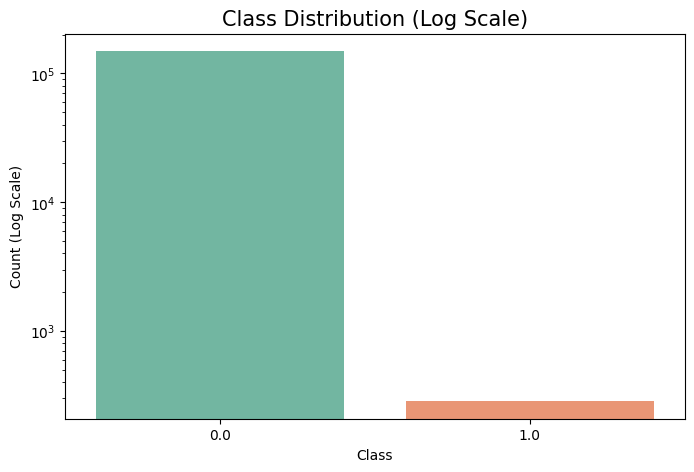

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Class",
    data=sample_df,
    palette="Set2"
)

plt.yscale("log")

plt.title("Class Distribution (Log Scale)", fontsize=15)

plt.xlabel("Class")

plt.ylabel("Count (Log Scale)")

plt.show()

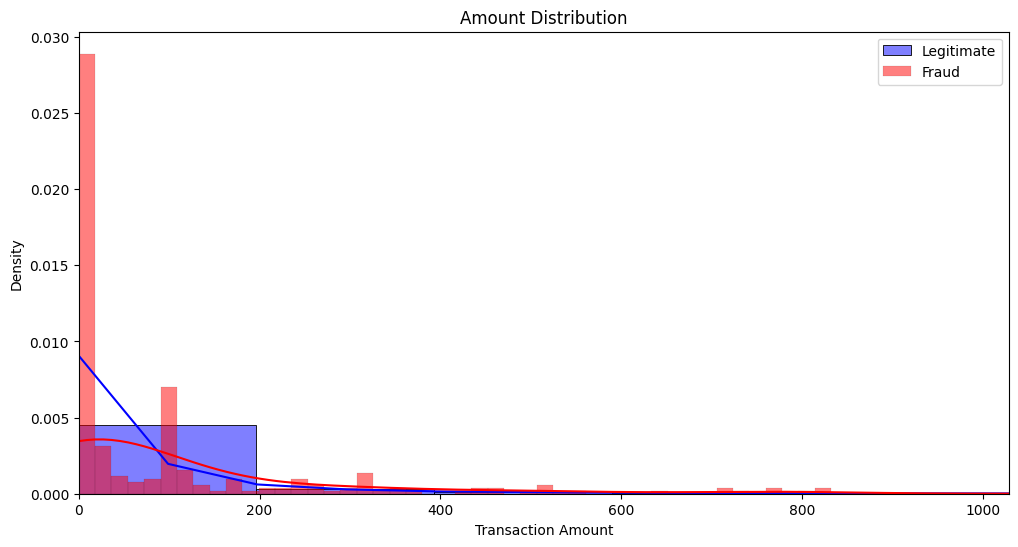

In [57]:
plt.figure(figsize=(12,6))

sns.histplot(
    sample_df[sample_df["Class"]==0]["Amount"],
    bins=100,
    color="blue",
    label="Legitimate",
    stat="density",
    kde=True,
    alpha=0.5
)

sns.histplot(
    sample_df[sample_df["Class"]==1]["Amount"],
    bins=100,
    color="red",
    label="Fraud",
    stat="density",
    kde=True,
    alpha=0.5
)

plt.xlim(0,sample_df["Amount"].quantile(0.99))

plt.title("Amount Distribution")

plt.xlabel("Transaction Amount")

plt.ylabel("Density")

plt.legend()

plt.show()

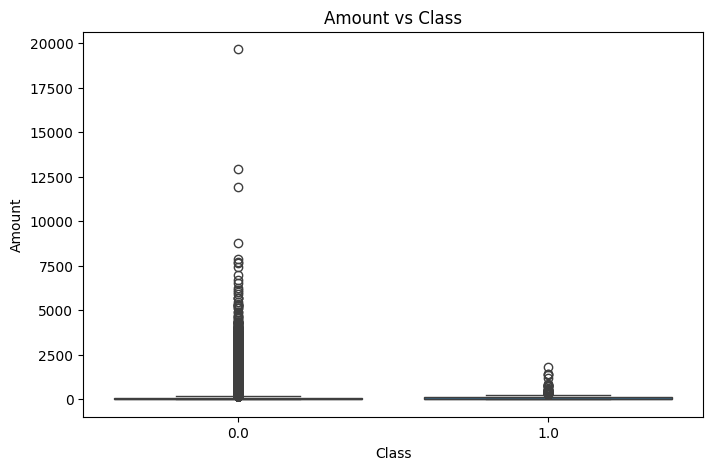

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=sample_df
)

plt.title("Amount vs Class")

plt.show()

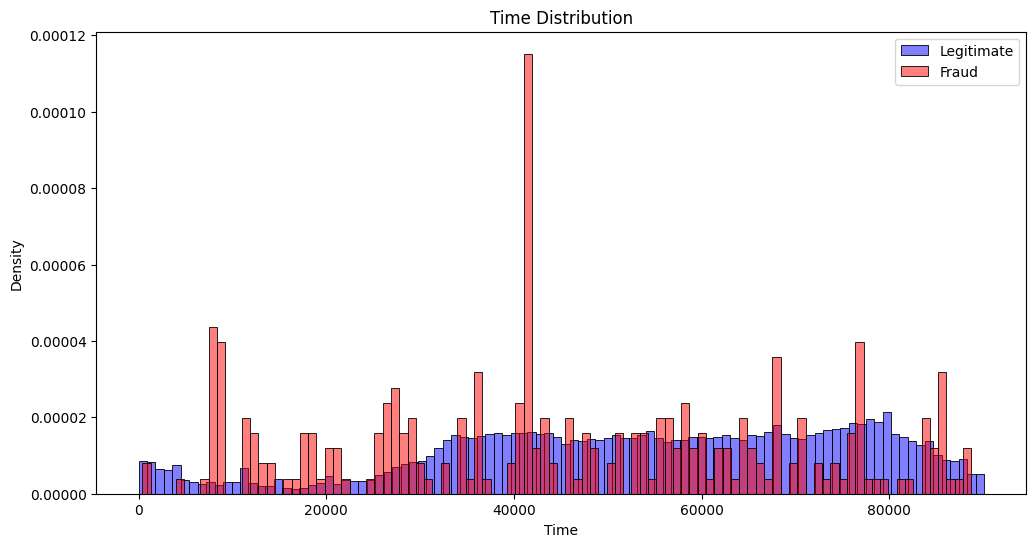

In [59]:
plt.figure(figsize=(12,6))

sns.histplot(
    sample_df[sample_df["Class"]==0]["Time"],
    bins=100,
    color="blue",
    stat="density",
    label="Legitimate",
    alpha=0.5
)

sns.histplot(
    sample_df[sample_df["Class"]==1]["Time"],
    bins=100,
    color="red",
    stat="density",
    label="Fraud",
    alpha=0.5
)

plt.title("Time Distribution")

plt.xlabel("Time")

plt.ylabel("Density")

plt.legend()

plt.show()

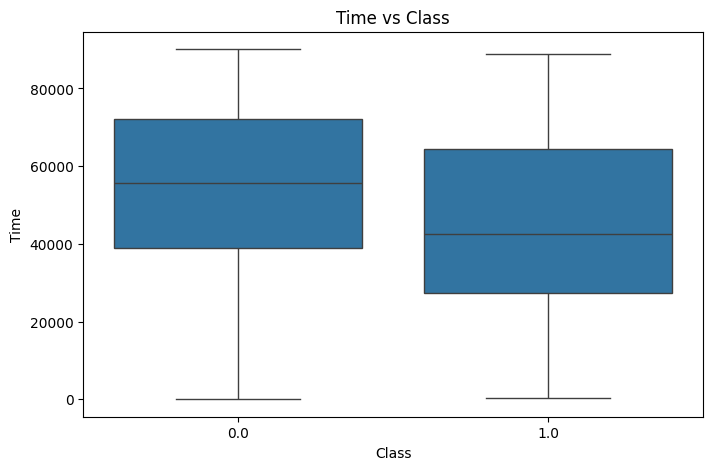

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Time",
    data=sample_df
)

plt.title("Time vs Class")

plt.show()

In [61]:
corr_columns = [

"V1","V2","V3","V4","V5",

"V6","V7","V8","V9","V10",

"Class"

]

corr = sample_df[corr_columns].corr()

corr

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
V1,1.000000,-0.005436,0.186395,-0.038489,0.005705,0.051545,0.077738,-0.013034,-0.057770,-0.024499,-0.124175
V2,-0.005436,1.000000,-0.100485,0.026203,-0.036368,0.012528,-0.011199,0.003863,0.007780,0.039663,0.102728
V3,0.186395,-0.100485,1.000000,-0.047947,0.140186,-0.072795,0.166503,-0.098022,0.081082,0.053565,-0.260108
V4,-0.038489,0.026203,-0.047947,1.000000,0.004544,-0.031751,-0.008768,0.027074,0.023983,-0.073704,0.142559
V5,0.005705,-0.036368,0.140186,0.004544,1.000000,0.061951,-0.018005,-0.017133,0.021152,0.041682,-0.120312
V6,0.051545,0.012528,-0.072795,-0.031751,0.061951,1.000000,0.014701,-0.041619,0.032574,-0.018381,-0.051750
V7,0.077738,-0.011199,0.166503,-0.008768,-0.018005,0.014701,1.000000,0.029331,0.035896,0.047789,-0.213118
V8,-0.013034,0.003863,-0.098022,0.027074,-0.017133,-0.041619,0.029331,1.000000,-0.002291,-0.016646,0.050168
V9,-0.057770,0.007780,0.081082,0.023983,0.021152,0.032574,0.035896,-0.002291,1.000000,-0.010395,-0.102130
V10,-0.024499,0.039663,0.053565,-0.073704,0.041682,-0.018381,0.047789,-0.016646,-0.010395,1.000000,-0.234123


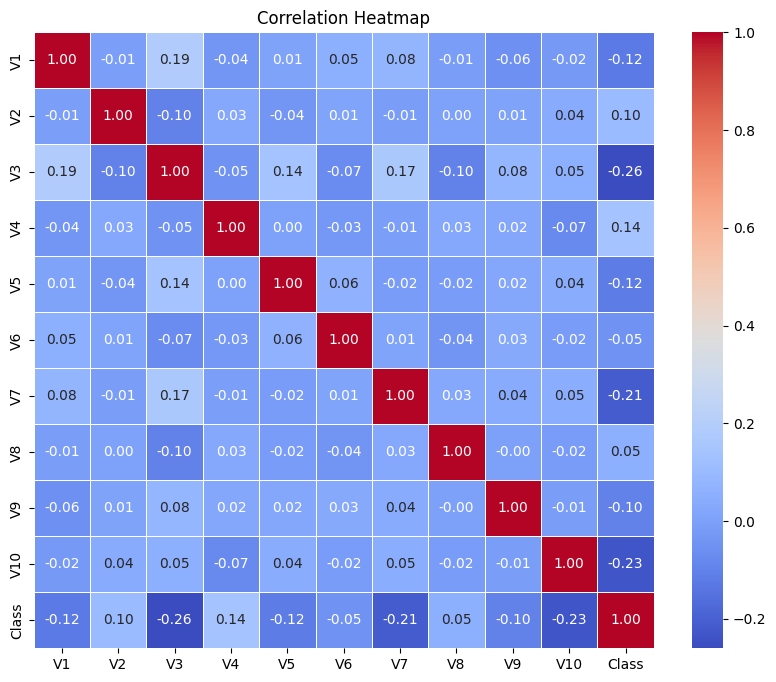

In [62]:
plt.figure(figsize=(10,8))

sns.heatmap(

corr,

annot=True,

fmt=".2f",

cmap="coolwarm",

linewidths=0.5

)

plt.title("Correlation Heatmap")

plt.show()

In [63]:
corr["Class"].sort_values(
    ascending=False
)

,Class
Class,1.000000
V4,0.142559
V2,0.102728
V8,0.050168
V6,-0.051750
V9,-0.102130
V5,-0.120312
V1,-0.124175
V7,-0.213118
V10,-0.234123


In [64]:
positive_corr = corr["Class"].sort_values(
    ascending=False
)

positive_corr

,Class
Class,1.000000
V4,0.142559
V2,0.102728
V8,0.050168
V6,-0.051750
V9,-0.102130
V5,-0.120312
V1,-0.124175
V7,-0.213118
V10,-0.234123


In [65]:
negative_corr = corr["Class"].sort_values()

negative_corr

,Class
V3,-0.260108
V10,-0.234123
V7,-0.213118
V1,-0.124175
V5,-0.120312
V9,-0.102130
V6,-0.051750
V8,0.050168
V2,0.102728
V4,0.142559


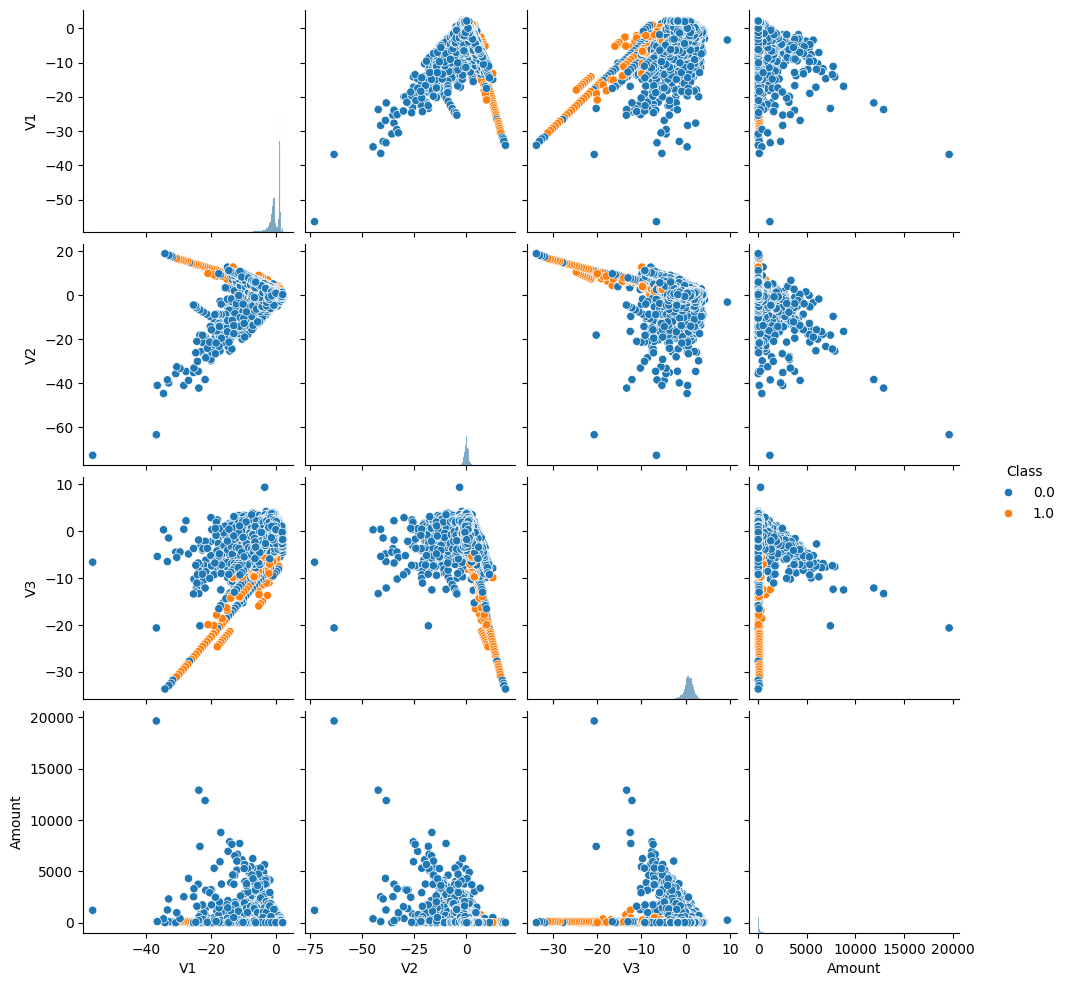

In [67]:
pair_columns = [

"V1",

"V2",

"V3",

"Amount",

"Class"

]

sns.pairplot(

sample_df[pair_columns],

hue="Class",

diag_kind="hist"

)

plt.show()

In [80]:
data = sample_df.copy()

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [69]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [70]:
print("Total Missing Values :", data.isnull().sum().sum())

Total Missing Values : 13


In [81]:
data["Amount_log"] = np.log1p(data["Amount"])

data[["Amount","Amount_log"]].head()

,Amount,Amount_log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


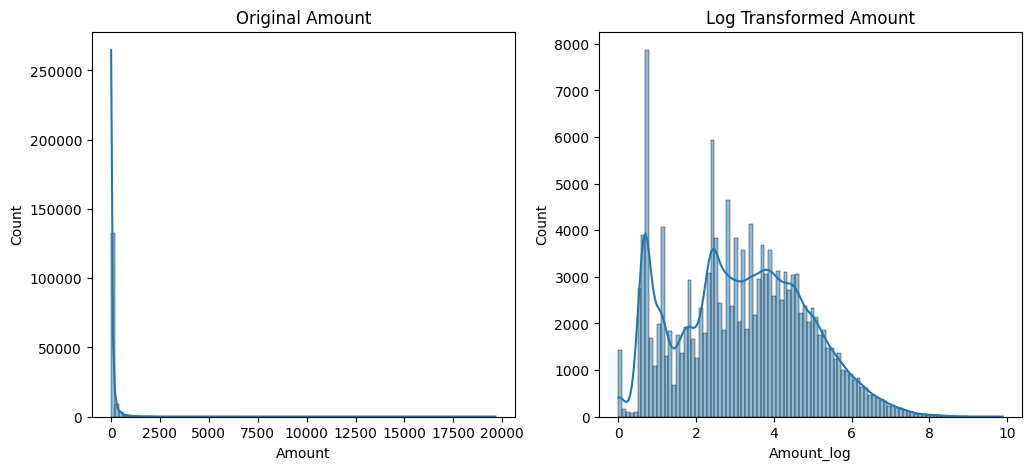

In [72]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    data["Amount"],
    bins=100,
    kde=True
)

plt.title("Original Amount")

plt.subplot(1,2,2)

sns.histplot(
    data["Amount_log"],
    bins=100,
    kde=True
)

plt.title("Log Transformed Amount")

plt.show()

In [82]:
data["Hour"] = (
    data["Time"] % 86400
) // 3600

data[["Time","Hour"]].head()

,Time,Hour
0,0,0
1,0,0
2,1,0
3,1,0
4,2,0


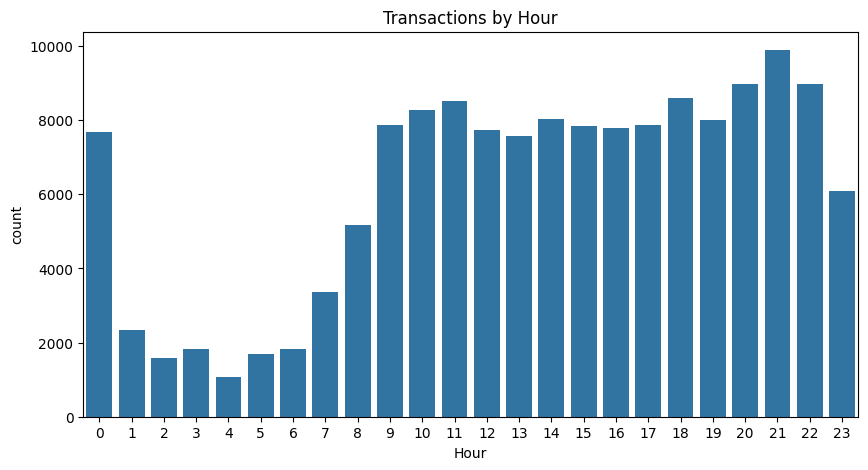

In [74]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Hour",
    data=data
)

plt.title("Transactions by Hour")

plt.show()

In [83]:
data.drop(
    columns=[
        "Time",
        "Amount"
    ],
    inplace=True
)
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,5.014760,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,1.305626,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,5.939276,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,4.824306,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,4.262539,0


In [84]:
X = data.drop(
    "Class",
    axis=1
)

y = data["Class"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (148636, 30)
Target Shape : (148636,)


In [85]:
not_nan_mask = y.notna()
X_filtered = X[not_nan_mask]
y_filtered = y[not_nan_mask]

X_train, X_test, y_train, y_test = train_test_split(

    X_filtered,

    y_filtered,

    test_size=0.20,

    stratify=y_filtered,

    random_state=42

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

print("Training Class Distribution")

print(y_train.value_counts())

print()

print("Testing Class Distribution")

print(y_test.value_counts())

Training Shape : (118908, 30)
Testing Shape : (29727, 30)
Training Class Distribution
Class
0.0    118680
1.0       228
Name: count, dtype: int64

Testing Class Distribution
Class
0.0    29670
1.0       57
Name: count, dtype: int64


In [86]:
scaler = StandardScaler()

X_train[
    ["Amount_log","Hour"]
] = scaler.fit_transform(

    X_train[
        ["Amount_log","Hour"]
    ]

)

X_test[
    ["Amount_log","Hour"]
] = scaler.transform(

    X_test[
        ["Amount_log","Hour"]
    ]

)

X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour
8978,1.305319,0.005576,0.484955,0.269736,-0.383559,-0.416178,-0.246826,-0.229663,1.972151,-0.754754,...,-0.290394,-0.289865,-0.116812,-0.051512,0.516266,1.101743,-0.088170,-0.010255,-1.033189,-1.733628
135915,-1.554461,0.007117,1.186577,1.664977,0.589571,-0.460580,-0.197348,0.558267,-0.587606,-0.549118,...,0.146475,0.101704,-0.128489,0.109029,0.090873,-0.210164,0.044202,-0.118717,0.164086,1.302992
118173,-0.776242,0.236556,2.337166,0.176708,-0.080839,-0.037250,-0.044607,0.189601,0.243600,-0.749476,...,-0.001424,0.034787,-0.133768,-0.076049,-0.033563,0.324921,0.078657,0.113091,0.098783,0.983348
128181,-1.077360,1.830702,-1.091829,0.278026,0.892418,0.600352,0.275664,0.603063,-0.541548,0.612880,...,0.240922,0.530407,-0.115962,-1.721270,-0.697445,-0.386695,-0.606574,-0.082943,-1.287160,1.143170
3237,-0.416537,0.563701,1.178576,-2.088132,0.002606,-1.330792,0.978318,-0.227902,0.776433,-0.939170,...,0.109121,0.587664,-0.266079,0.502140,-0.032571,-0.864763,0.225970,-0.024861,-1.494001,-2.213094


In [88]:
smote = SMOTE(

    sampling_strategy=0.1,

    random_state=42

)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train,

    y_train

)

print("SMOTE Class Distribution")

print(y_train_smote.value_counts())

SMOTE Class Distribution
Class
0.0    118680
1.0     11868
Name: count, dtype: int64


In [89]:
under = RandomUnderSampler(

    sampling_strategy=0.1,

    random_state=42

)

X_train_under, y_train_under = under.fit_resample(

    X_train,

    y_train

)

print("Under Sampling Distribution")

print(y_train_under.value_counts())

Under Sampling Distribution
Class
0.0    2280
1.0     228
Name: count, dtype: int64


In [90]:
comparison = pd.DataFrame({

    "Original":y_train.value_counts(),

    "SMOTE":y_train_smote.value_counts(),

    "UnderSampling":y_train_under.value_counts()

})

comparison

,Original,SMOTE,UnderSampling
Class,,,
0.0,118680,118680,2280
1.0,228,11868,228


In [91]:
print("="*50)

print("Original Training Shape")

print(X_train.shape)

print()

print("SMOTE Shape")

print(X_train_smote.shape)

print()

print("Under Sampling Shape")

print(X_train_under.shape)

print("="*50)

Original Training Shape
(118908, 30)

SMOTE Shape
(130548, 30)

Under Sampling Shape
(2508, 30)


In [92]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    print("="*60)

    print(model_name)

    print("="*60)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1 Score :", f1)

    print("PR AUC :", pr_auc)

    print()

    print(classification_report(
        y_test,
        y_pred
    ))

    return {

        "Model":model_name,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

        "PR AUC":pr_auc

    }

In [93]:
lr_original = LogisticRegression(

    class_weight="balanced",

    max_iter=1000,

    random_state=42

)

lr_original.fit(

    X_train,

    y_train

)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [94]:
result_original = evaluate_model(

    lr_original,

    X_test,

    y_test,

    "Logistic Regression - Original"

)

Logistic Regression - Original
Precision : 0.0737134909596662
Recall : 0.9298245614035088
F1 Score : 0.13659793814432988
PR AUC : 0.7311671981139587

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     29670
         1.0       0.07      0.93      0.14        57

    accuracy                           0.98     29727
   macro avg       0.54      0.95      0.56     29727
weighted avg       1.00      0.98      0.99     29727



In [95]:
lr_smote = LogisticRegression(

    max_iter=1000,

    random_state=42

)

lr_smote.fit(

    X_train_smote,

    y_train_smote

)

LogisticRegression(max_iter=1000, random_state=42)

In [96]:
result_smote = evaluate_model(

    lr_smote,

    X_test,

    y_test,

    "Logistic Regression - SMOTE"

)

Logistic Regression - SMOTE
Precision : 0.36619718309859156
Recall : 0.9122807017543859
F1 Score : 0.5226130653266332
PR AUC : 0.7747072461281183

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     29670
         1.0       0.37      0.91      0.52        57

    accuracy                           1.00     29727
   macro avg       0.68      0.95      0.76     29727
weighted avg       1.00      1.00      1.00     29727



In [97]:
lr_under = LogisticRegression(

    max_iter=1000,

    random_state=42

)

lr_under.fit(

    X_train_under,

    y_train_under

)

LogisticRegression(max_iter=1000, random_state=42)

In [98]:
result_under = evaluate_model(

    lr_under,

    X_test,

    y_test,

    "Logistic Regression - UnderSampling"

)

Logistic Regression - UnderSampling
Precision : 0.22566371681415928
Recall : 0.8947368421052632
F1 Score : 0.36042402826855124
PR AUC : 0.7584904627767313

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     29670
         1.0       0.23      0.89      0.36        57

    accuracy                           0.99     29727
   macro avg       0.61      0.94      0.68     29727
weighted avg       1.00      0.99      1.00     29727



In [99]:
lr_results = pd.DataFrame([

    result_original,

    result_smote,

    result_under

])

lr_results

,Model,Precision,Recall,F1 Score,PR AUC
0,Logistic Regression - Original,0.073713,0.929825,0.136598,0.731167
1,Logistic Regression - SMOTE,0.366197,0.912281,0.522613,0.774707
2,Logistic Regression - UnderSampling,0.225664,0.894737,0.360424,0.758490


In [100]:
lr_results.sort_values(

    by="PR AUC",

    ascending=False

)

,Model,Precision,Recall,F1 Score,PR AUC
1,Logistic Regression - SMOTE,0.366197,0.912281,0.522613,0.774707
2,Logistic Regression - UnderSampling,0.225664,0.894737,0.360424,0.758490
0,Logistic Regression - Original,0.073713,0.929825,0.136598,0.731167


In [87]:
rf = RandomForestClassifier(

    n_estimators=100,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

rf.fit(

    X_train,

    y_train

)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [101]:
rf_result = evaluate_model(

    rf,

    X_test,

    y_test,

    "Random Forest"

)

Random Forest
Precision : 0.9787234042553191
Recall : 0.8070175438596491
F1 Score : 0.8846153846153846
PR AUC : 0.893860355935278

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     29670
         1.0       0.98      0.81      0.88        57

    accuracy                           1.00     29727
   macro avg       0.99      0.90      0.94     29727
weighted avg       1.00      1.00      1.00     29727



In [102]:
rf_prob = rf.predict_proba(

    X_test

)[:,1]

In [103]:
prc_output = precision_recall_curve(

    y_test,

    rf_prob

)

precision = prc_output[0]

recall = prc_output[1]

threshold = prc_output[2]

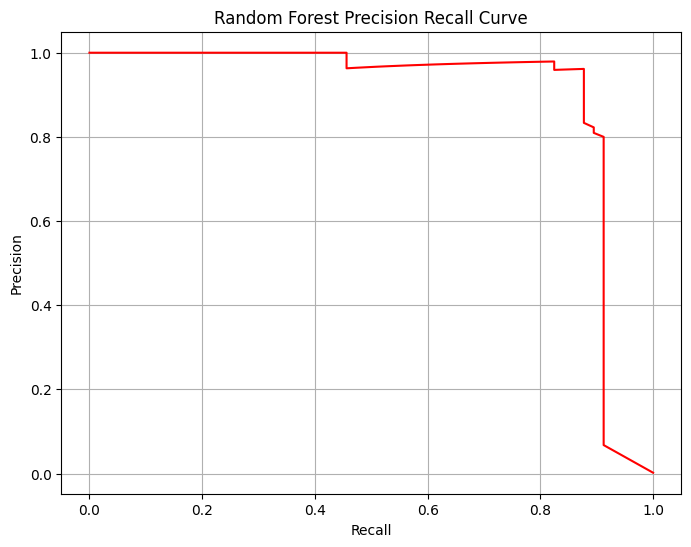

In [104]:
plt.figure(figsize=(8,6))

plt.plot(

    recall,

    precision,

    color="red"

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Random Forest Precision Recall Curve")

plt.grid(True)

plt.show()

In [133]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

importance.head()

,Feature,Importance
0,V1,0.006788
1,V2,0.020636
2,V3,0.086347
3,V4,0.085618
4,V5,0.012635


In [134]:
importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(10)

,Feature,Importance
13,V14,0.224558
9,V10,0.107903
11,V12,0.092949
16,V17,0.088153
2,V3,0.086347
3,V4,0.085618
10,V11,0.055592
15,V16,0.042318
6,V7,0.024426
1,V2,0.020636


/tmp/ipykernel_767/2206172107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


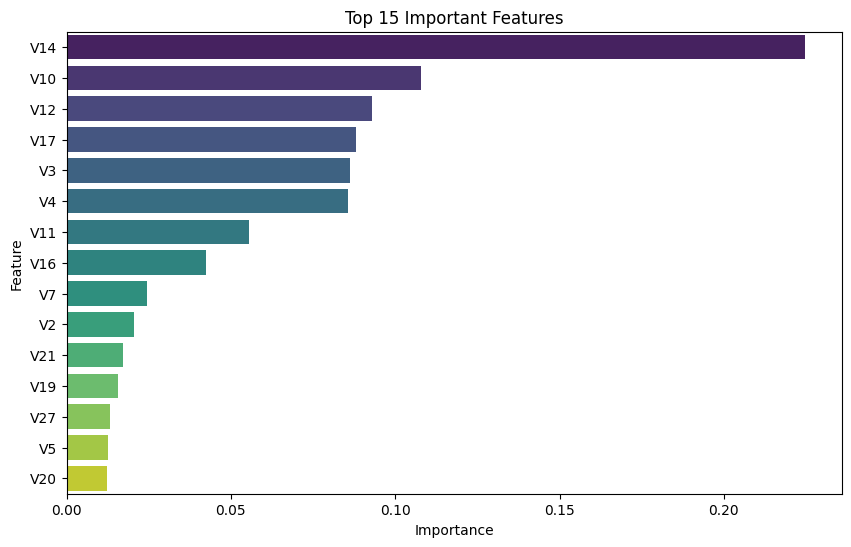

In [135]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Important Features")

plt.show()

In [108]:
pred = rf.predict(X_test)

cm = confusion_matrix(

    y_test,

    pred

)

cm

array([[29669,     1],
       [   11,    46]])

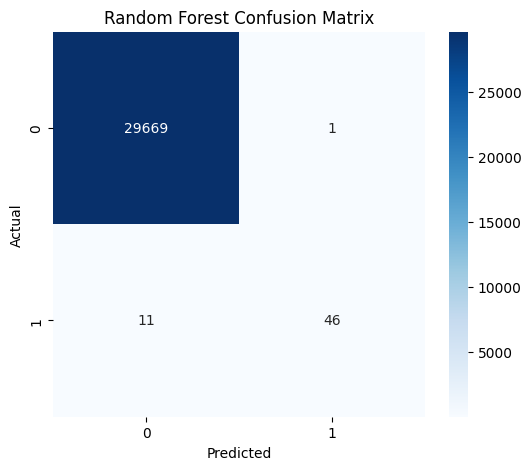

In [109]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [110]:
comparison = pd.DataFrame([

    result_original,

    result_smote,

    result_under,

    rf_result

])

comparison

,Model,Precision,Recall,F1 Score,PR AUC
0,Logistic Regression - Original,0.073713,0.929825,0.136598,0.731167
1,Logistic Regression - SMOTE,0.366197,0.912281,0.522613,0.774707
2,Logistic Regression - UnderSampling,0.225664,0.894737,0.360424,0.758490
3,Random Forest,0.978723,0.807018,0.884615,0.893860


In [111]:
comparison.sort_values(

    by="PR AUC",

    ascending=False

)

,Model,Precision,Recall,F1 Score,PR AUC
3,Random Forest,0.978723,0.807018,0.884615,0.893860
1,Logistic Regression - SMOTE,0.366197,0.912281,0.522613,0.774707
2,Logistic Regression - UnderSampling,0.225664,0.894737,0.360424,0.758490
0,Logistic Regression - Original,0.073713,0.929825,0.136598,0.731167


In [112]:
precision,

recall,

threshold = precision_recall_curve(

    y_test,

    rf_prob

)

In [114]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

precision, recall, thresholds = precision_recall_curve(y_test, rf_prob)

In [115]:
rf_prob = rf.predict_proba(X_test)[:, 1]

In [116]:
print(type(rf_prob))
print(rf_prob.shape)

print(type(y_test))
print(y_test.shape)

<class 'numpy.ndarray'>
(29727,)
<class 'pandas.core.series.Series'>
(29727,)


In [117]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

print("Scale Positive Weight :", ratio)

Scale Positive Weight : 520.5263157894736


In [118]:
xgb = XGBClassifier(

    n_estimators=200,

    learning_rate=0.1,

    max_depth=4,

    scale_pos_weight=ratio,

    random_state=42,

    eval_metric="logloss"

)

xgb.fit(

    X_train,

    y_train

)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [119]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

In [120]:
print(classification_report(
    y_test,
    xgb_pred
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     29670
         1.0       0.91      0.88      0.89        57

    accuracy                           1.00     29727
   macro avg       0.95      0.94      0.95     29727
weighted avg       1.00      1.00      1.00     29727



In [121]:
print("Precision :", precision_score(y_test,xgb_pred))

print("Recall :", recall_score(y_test,xgb_pred))

print("F1 :", f1_score(y_test,xgb_pred))

print("PR AUC :", average_precision_score(y_test,xgb_prob))

Precision : 0.9090909090909091
Recall : 0.8771929824561403
F1 : 0.8928571428571429
PR AUC : 0.9079324106014575


In [122]:
precision_xgb, recall_xgb, thresholds = precision_recall_curve(

    y_test,

    xgb_prob

)

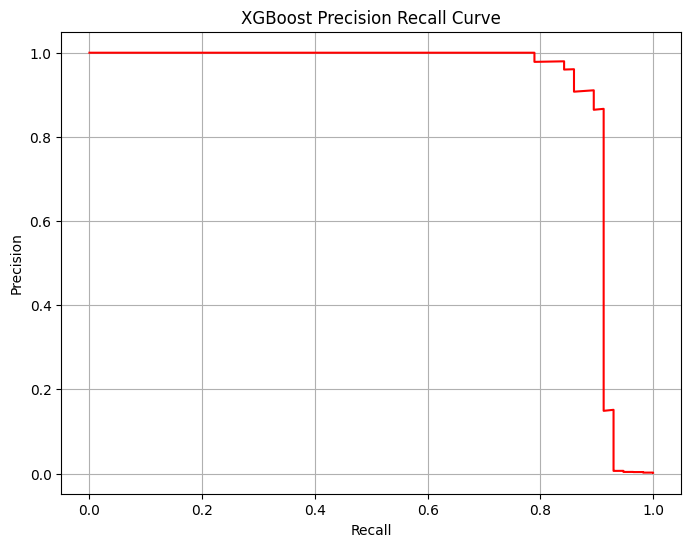

In [123]:
plt.figure(figsize=(8,6))

plt.plot(

    recall_xgb,

    precision_xgb,

    color="red"

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("XGBoost Precision Recall Curve")

plt.grid(True)

plt.show()

In [124]:
params = {

    "n_estimators":[100,200,300],

    "max_depth":[3,4,5,6],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.6,0.8,1.0],

    "colsample_bytree":[0.6,0.8,1.0]

}

In [125]:
xgb_model = XGBClassifier(

    scale_pos_weight=ratio,

    random_state=42,

    eval_metric="logloss"

)

In [126]:
random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=params,

    n_iter=15,

    scoring="average_precision",

    cv=3,

    random_state=42,

    verbose=2,

    n_jobs=-1

)

random_search.fit(

    X_train,

    y_train

)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=2)

In [127]:
print("Best Parameters")

print(random_search.best_params_)

Best Parameters
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [128]:
print("Best PR AUC")

print(random_search.best_score_)

Best PR AUC
0.8651597637170348


In [129]:
best_xgb = random_search.best_estimator_

best_prob = best_xgb.predict_proba(

    X_test

)[:,1]

In [130]:
precision,

recall,

thresholds = precision_recall_curve(

    y_test,

    best_prob

)

In [131]:
f1_scores = (

2 *

precision[:-1] *

recall[:-1]

/

(

precision[:-1]

+

recall[:-1]

+

1e-10

)

)

In [136]:
best_index = np.argmax(

    f1_scores

)

best_threshold = thresholds[2][best_index]

print(best_threshold)

3.029171e-09


In [137]:
print("Best F1 Score")

print(f1_scores[best_index])

Best F1 Score
0.9174311926106556


In [138]:
pred_best = (

best_prob >= best_threshold

).astype(int)

In [139]:
print(classification_report(

    y_test,

    pred_best

))

              precision    recall  f1-score   support

         0.0       1.00      0.00      0.00     29670
         1.0       0.00      1.00      0.00        57

    accuracy                           0.00     29727
   macro avg       0.50      0.50      0.00     29727
weighted avg       1.00      0.00      0.00     29727



In [140]:
index = np.where(

recall[:-1] >= 0.90

)[0]

In [141]:
best_index = index[

np.argmax(

precision[:-1][index]

)

]

In [143]:
threshold_90 = thresholds[2][best_index]

print(threshold_90)

2.3325077e-09


In [144]:
print("Precision")

print(

precision[best_index]

)

print()

print("Recall")

print(

recall[best_index]

)

Precision
0.8

Recall
0.9122807017543859


In [145]:
comparison = pd.DataFrame({

"Threshold":[

0.5,

best_threshold,

threshold_90

],

"Precision":[

precision_score(

y_test,

(best_prob>=0.5).astype(int)

),

precision_score(

y_test,

pred_best

),

precision_score(

y_test,

(best_prob>=threshold_90).astype(int)

)

],

"Recall":[

recall_score(

y_test,

(best_prob>=0.5).astype(int)

),

recall_score(

y_test,

pred_best

),

recall_score(

y_test,

(best_prob>=threshold_90).astype(int)

)

],

"F1":[

f1_score(

y_test,

(best_prob>=0.5).astype(int)

),

f1_score(

y_test,

pred_best

),

f1_score(

y_test,

(best_prob>=threshold_90).astype(int)

)

]

})

comparison

,Threshold,Precision,Recall,F1
0,5.000000e-01,0.961538,0.877193,0.917431
1,3.029171e-09,0.001919,1.000000,0.003830
2,2.332508e-09,0.001918,1.000000,0.003829


In [146]:
# Logistic Regression Results

result_original

result_smote

result_under

# Random Forest Result

rf_result

{'Model': 'Random Forest',
 'Precision': 0.9787234042553191,
 'Recall': 0.8070175438596491,
 'F1 Score': 0.8846153846153846,
 'PR AUC': np.float64(0.893860355935278)}

In [147]:
final_results = pd.DataFrame([

    result_original,

    result_smote,

    result_under,

    rf_result

])

In [148]:
xgb_result = {

    "Model": "XGBoost Baseline",

    "Precision": precision_score(
        y_test,
        xgb.predict(X_test),
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        xgb.predict(X_test),
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        xgb.predict(X_test),
        zero_division=0
    ),

    "PR AUC": average_precision_score(
        y_test,
        xgb_prob
    )

}

In [150]:
tuned_xgb_pred = (
    best_prob >= 0.5
).astype(int)

tuned_xgb_result = {

    "Model": "XGBoost Tuned",

    "Precision": precision_score(
        y_test,
        tuned_xgb_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        tuned_xgb_pred,
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        tuned_xgb_pred,
        zero_division=0
    ),

    "PR AUC": average_precision_score(
        y_test,
        best_prob
    )

}

In [151]:
final_results = pd.DataFrame([

    result_original,

    result_smote,

    result_under,

    rf_result,

    xgb_result,

    tuned_xgb_result

])

final_results

,Model,Precision,Recall,F1 Score,PR AUC
0,Logistic Regression - Original,0.073713,0.929825,0.136598,0.731167
1,Logistic Regression - SMOTE,0.366197,0.912281,0.522613,0.774707
2,Logistic Regression - UnderSampling,0.225664,0.894737,0.360424,0.758490
3,Random Forest,0.978723,0.807018,0.884615,0.893860
4,XGBoost Baseline,0.909091,0.877193,0.892857,0.907932
5,XGBoost Tuned,0.961538,0.877193,0.917431,0.900048


In [152]:
final_results_sorted = final_results.sort_values(

    by="PR AUC",

    ascending=False

)

final_results_sorted

,Model,Precision,Recall,F1 Score,PR AUC
4,XGBoost Baseline,0.909091,0.877193,0.892857,0.907932
5,XGBoost Tuned,0.961538,0.877193,0.917431,0.900048
3,Random Forest,0.978723,0.807018,0.884615,0.893860
1,Logistic Regression - SMOTE,0.366197,0.912281,0.522613,0.774707
2,Logistic Regression - UnderSampling,0.225664,0.894737,0.360424,0.758490
0,Logistic Regression - Original,0.073713,0.929825,0.136598,0.731167


In [153]:
best_model = final_results_sorted.iloc[0]

best_model

,4
Model,XGBoost Baseline
Precision,0.909091
Recall,0.877193
F1 Score,0.892857
PR AUC,0.907932


In [154]:
print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Best PR-AUC:",
    best_model["PR AUC"]
)

Best Model: XGBoost Baseline
Best PR-AUC: 0.9079324106014575


In [157]:
# Logistic Regression Probability

lr_prob = lr_original.predict_proba(
    X_test
)[:, 1]

# Random Forest Probability

rf_prob = rf.predict_proba(
    X_test
)[:, 1]

# XGBoost Baseline Probability

xgb_prob = xgb.predict_proba(
    X_test
)[:, 1]

# Tuned XGBoost Probability

best_prob = best_xgb.predict_proba(
    X_test
)[:, 1]

In [159]:
precision_lr, recall_lr, _ = precision_recall_curve(

    y_test,

    lr_prob

)

precision_rf, recall_rf, _ = precision_recall_curve(

    y_test,

    rf_prob

)

precision_xgb, recall_xgb, _ = precision_recall_curve(

    y_test,

    xgb_prob

)

precision_tuned, recall_tuned, _ = precision_recall_curve(

    y_test,

    best_prob

)

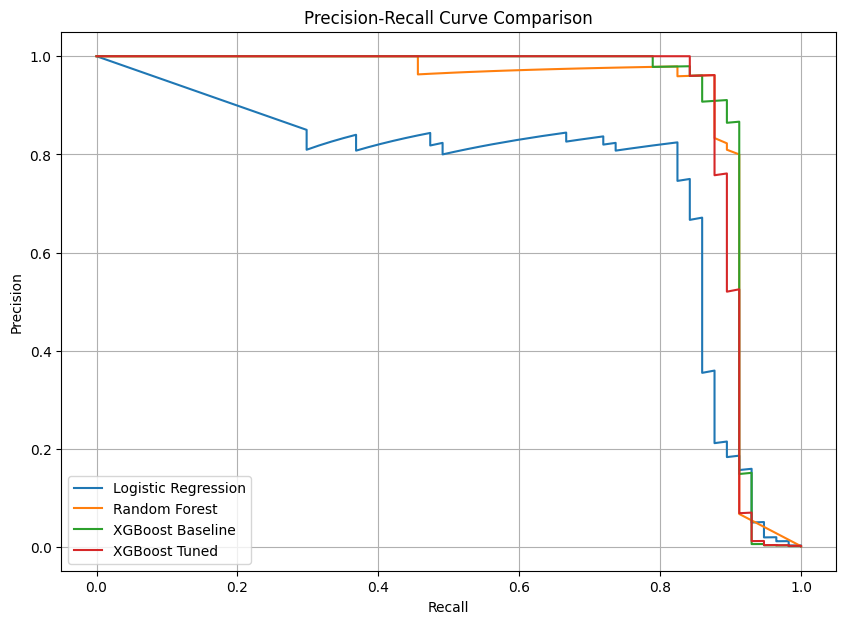

In [160]:
plt.figure(figsize=(10,7))

plt.plot(

    recall_lr,

    precision_lr,

    label="Logistic Regression"

)

plt.plot(

    recall_rf,

    precision_rf,

    label="Random Forest"

)

plt.plot(

    recall_xgb,

    precision_xgb,

    label="XGBoost Baseline"

)

plt.plot(

    recall_tuned,

    precision_tuned,

    label="XGBoost Tuned"

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()

plt.grid(True)

plt.show()

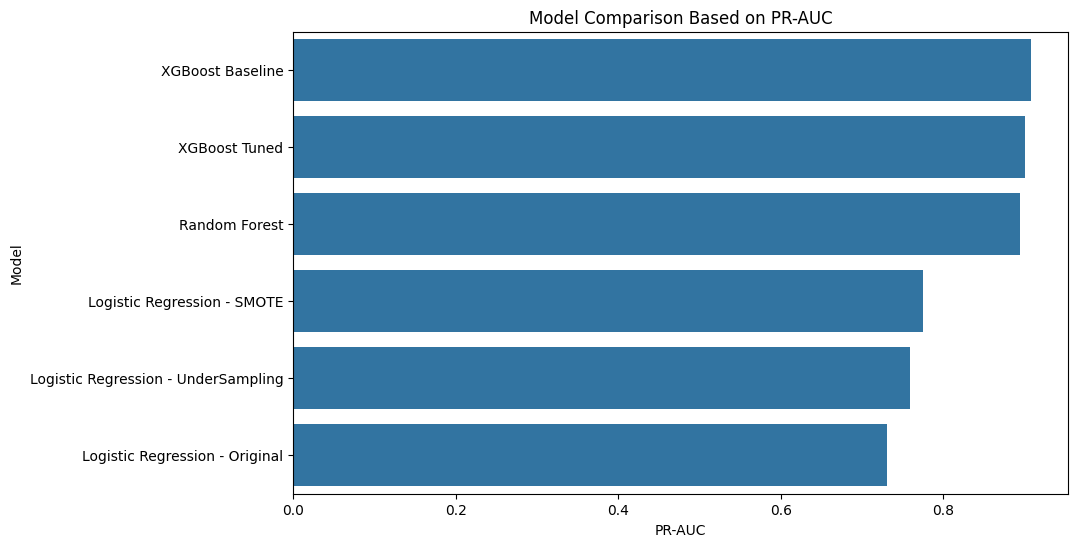

In [161]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=final_results_sorted,

    x="PR AUC",

    y="Model"

)

plt.title(
    "Model Comparison Based on PR-AUC"
)

plt.xlabel("PR-AUC")

plt.ylabel("Model")

plt.show()

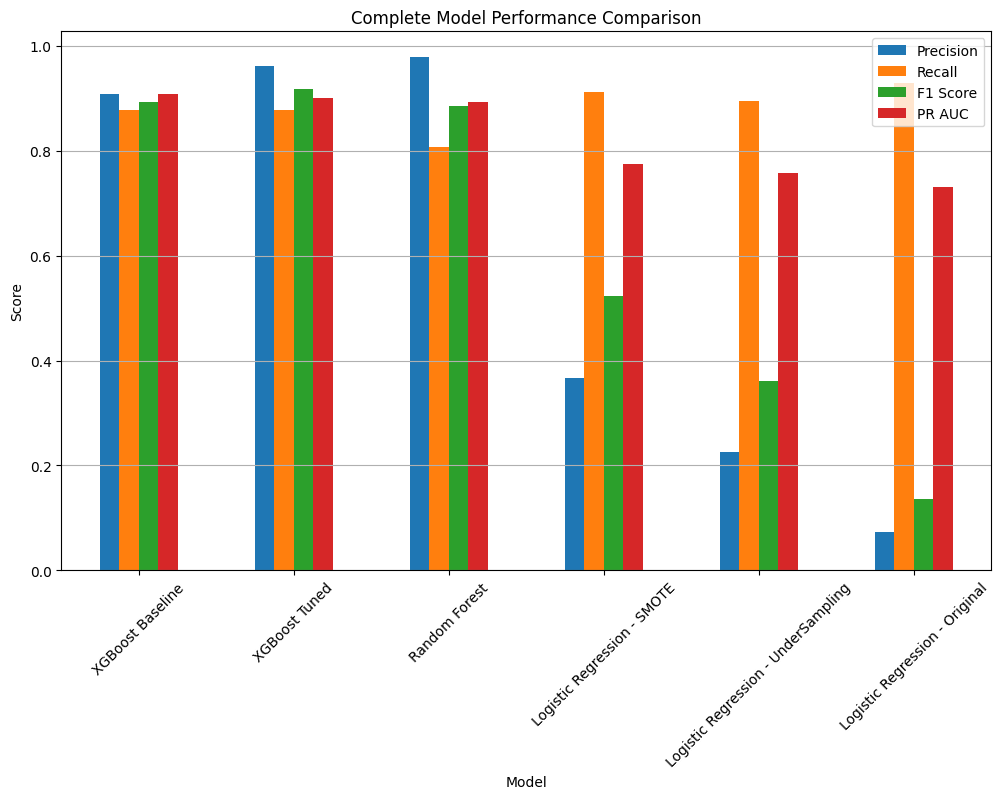

In [162]:
final_results_sorted.set_index(
    "Model"
)[
    [
        "Precision",
        "Recall",
        "F1 Score",
        "PR AUC"
    ]
].plot(

    kind="bar",

    figsize=(12,7)

)

plt.title(
    "Complete Model Performance Comparison"
)

plt.ylabel("Score")

plt.xticks(
    rotation=45
)

plt.legend()

plt.grid(axis="y")

plt.show()

In [163]:
print("=" * 70)

print("FINAL MODEL COMPARISON")

print("=" * 70)

print(
    final_results_sorted.to_string(
        index=False
    )
)

print("=" * 70)

print(
    "BEST MODEL:",
    best_model["Model"]
)

print(
    "BEST PR-AUC:",
    best_model["PR AUC"]
)

print("=" * 70)

FINAL MODEL COMPARISON
                              Model  Precision   Recall  F1 Score   PR AUC
                   XGBoost Baseline   0.909091 0.877193  0.892857 0.907932
                      XGBoost Tuned   0.961538 0.877193  0.917431 0.900048
                      Random Forest   0.978723 0.807018  0.884615 0.893860
        Logistic Regression - SMOTE   0.366197 0.912281  0.522613 0.774707
Logistic Regression - UnderSampling   0.225664 0.894737  0.360424 0.758490
     Logistic Regression - Original   0.073713 0.929825  0.136598 0.731167
BEST MODEL: XGBoost Baseline
BEST PR-AUC: 0.9079324106014575


In [164]:
best_model_summary = pd.DataFrame({

    "Metric": [

        "Model",

        "Precision",

        "Recall",

        "F1 Score",

        "PR AUC"

    ],

    "Value": [

        best_model["Model"],

        best_model["Precision"],

        best_model["Recall"],

        best_model["F1 Score"],

        best_model["PR AUC"]

    ]

})

best_model_summary

,Metric,Value
0,Model,XGBoost Baseline
1,Precision,0.909091
2,Recall,0.877193
3,F1 Score,0.892857
4,PR AUC,0.907932


In [165]:
FRAUD_LOSS = 4500

INVESTIGATION_COST = 150

In [179]:
def calculate_business_metrics(y_true, y_prob, threshold):
    """
    Calculates business savings based on model predictions and business constants.
    """
    y_pred = (y_prob >= threshold).astype(int)

    # Get confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Business Calculations
    money_saved = tp * FRAUD_LOSS
    investigation_cost = (tp + fp) * INVESTIGATION_COST
    money_lost = fn * FRAUD_LOSS
    net_savings = money_saved - investigation_cost

    return {
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Money Saved": money_saved,
        "Investigation Cost": investigation_cost,
        "Money Lost (False Negatives)": money_lost,
        "Net Savings": net_savings
    }

In [180]:
# Calculate business metrics using the XGBoost Baseline and the standard 0.5 threshold
business_results = calculate_business_metrics(y_test, xgb_prob, threshold=0.5)

# Print the results formatted for business readability
print("--- Business Impact Analysis ---")
for metric, value in business_results.items():
    if isinstance(value, (int, float)) and value >= 1000:
        print(f"{metric}: ${value:,.2f}")
    else:
        print(f"{metric}: {value}")

--- Business Impact Analysis ---
TP: 50
FP: 5
FN: 7
TN: 29665
Money Saved: 225000
Investigation Cost: 8250
Money Lost (False Negatives): 31500
Net Savings: 216750


In [182]:
# Access the values from the business_results dictionary defined in the previous cell
net_benefit = (
    business_results['Money Saved']
    - business_results['Investigation Cost']
    - business_results['Money Lost (False Negatives)']
)

print(f"Total Net Business Benefit: ${net_benefit:,.2f}")

Total Net Business Benefit: $185,250.00


In [184]:
def get_business_summary(y_true, y_prob, threshold):
    """
    A helper function that returns all business metrics in a dictionary format.
    """
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    money_saved = tp * FRAUD_LOSS
    investigation_cost = (tp + fp) * INVESTIGATION_COST
    money_lost = fn * FRAUD_LOSS
    net_benefit = money_saved - investigation_cost - money_lost

    return {
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Money Saved": money_saved,
        "Investigation Cost": investigation_cost,
        "Money Lost": money_lost,
        "Net Benefit": net_benefit
    }

In [185]:
def calculate_business_metrics(

    y_true,

    y_prob,

    threshold

):

    y_pred = (

        y_prob >= threshold

    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(

        y_true,

        y_pred

    ).ravel()

    money_saved = tp * FRAUD_LOSS

    investigation_cost = (

        tp + fp

    ) * INVESTIGATION_COST

    money_lost = fn * FRAUD_LOSS

    net_benefit = (

        money_saved

        -

        investigation_cost

        -

        money_lost

    )

    return {

        "Threshold": threshold,

        "TN": tn,

        "FP": fp,

        "FN": fn,

        "TP": tp,

        "Money Saved": money_saved,

        "Investigation Cost": investigation_cost,

        "Money Lost": money_lost,

        "Net Benefit": net_benefit

    }

In [186]:
thresholds_to_test = [

    0.1,

    0.2,

    0.3,

    0.5,

    best_threshold

]

In [187]:
business_results = []

for threshold in thresholds_to_test:

    result = calculate_business_metrics(

        y_test,

        best_prob,

        threshold

    )

    business_results.append(result)

In [188]:
business_df = pd.DataFrame(

    business_results

)

business_df

,Threshold,TN,FP,FN,TP,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,1.000000e-01,29660,10,7,50,225000,9000,31500,184500
1,2.000000e-01,29664,6,7,50,225000,8400,31500,185100
2,3.000000e-01,29665,5,7,50,225000,8250,31500,185250
3,5.000000e-01,29668,2,7,50,225000,7800,31500,185700
4,3.029171e-09,17,29653,0,57,256500,4456500,0,-4200000


In [189]:
business_df_sorted = business_df.sort_values(

    by="Net Benefit",

    ascending=False

)

business_df_sorted

,Threshold,TN,FP,FN,TP,Money Saved,Investigation Cost,Money Lost,Net Benefit
3,5.000000e-01,29668,2,7,50,225000,7800,31500,185700
2,3.000000e-01,29665,5,7,50,225000,8250,31500,185250
1,2.000000e-01,29664,6,7,50,225000,8400,31500,185100
0,1.000000e-01,29660,10,7,50,225000,9000,31500,184500
4,3.029171e-09,17,29653,0,57,256500,4456500,0,-4200000


In [190]:
best_business_threshold = business_df.loc[

    business_df["Net Benefit"].idxmax(),

    "Threshold"

]

print(

    "Best Business Threshold:",

    best_business_threshold

)

Best Business Threshold: 0.5


In [191]:
best_net_benefit = business_df.loc[

    business_df["Net Benefit"].idxmax(),

    "Net Benefit"

]

print(

    "Best Net Benefit: ₹",

    best_net_benefit

)

Best Net Benefit: ₹ 185700


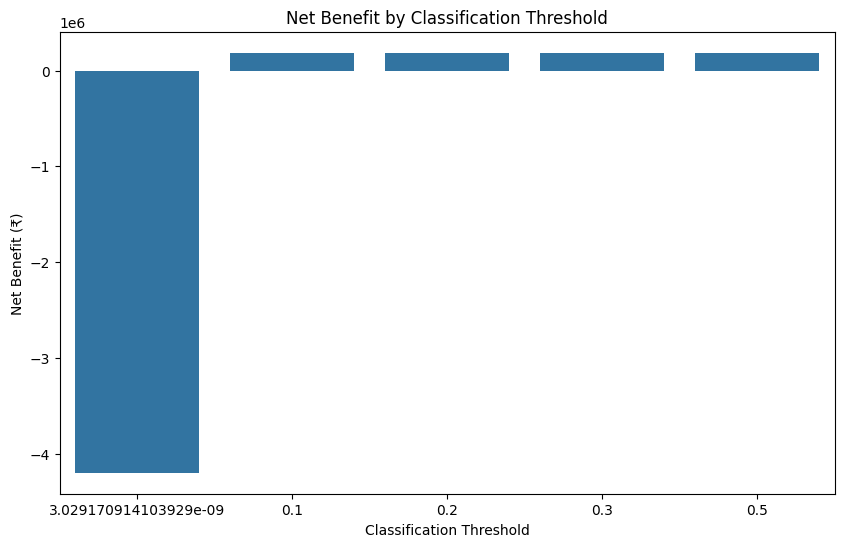

In [192]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=business_df,

    x="Threshold",

    y="Net Benefit"

)

plt.title(

    "Net Benefit by Classification Threshold"

)

plt.xlabel(

    "Classification Threshold"

)

plt.ylabel(

    "Net Benefit (₹)"

)

plt.show()

In [193]:
business_df[

    [

        "Threshold",

        "TP",

        "FP",

        "FN"

    ]

]

,Threshold,TP,FP,FN
0,1.000000e-01,50,10,7
1,2.000000e-01,50,6,7
2,3.000000e-01,50,5,7
3,5.000000e-01,50,2,7
4,3.029171e-09,57,29653,0


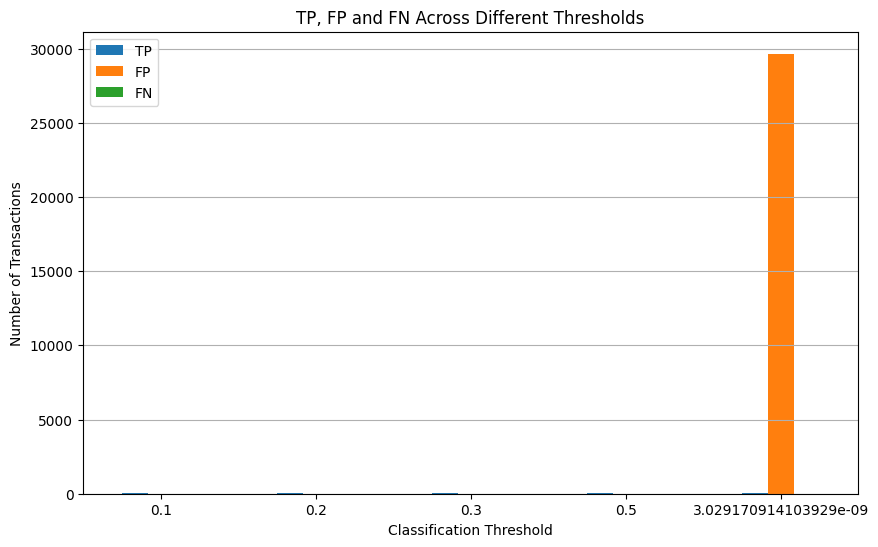

In [194]:
business_df.set_index(

    "Threshold"

)[

    [

        "TP",

        "FP",

        "FN"

    ]

].plot(

    kind="bar",

    figsize=(10,6)

)

plt.title(

    "TP, FP and FN Across Different Thresholds"

)

plt.xlabel(

    "Classification Threshold"

)

plt.ylabel(

    "Number of Transactions"

)

plt.xticks(

    rotation=0

)

plt.grid(

    axis="y"

)

plt.show()

In [195]:
financial_comparison = business_df[

    [

        "Threshold",

        "Money Saved",

        "Investigation Cost",

        "Money Lost",

        "Net Benefit"

    ]

]

financial_comparison

,Threshold,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,1.000000e-01,225000,9000,31500,184500
1,2.000000e-01,225000,8400,31500,185100
2,3.000000e-01,225000,8250,31500,185250
3,5.000000e-01,225000,7800,31500,185700
4,3.029171e-09,256500,4456500,0,-4200000


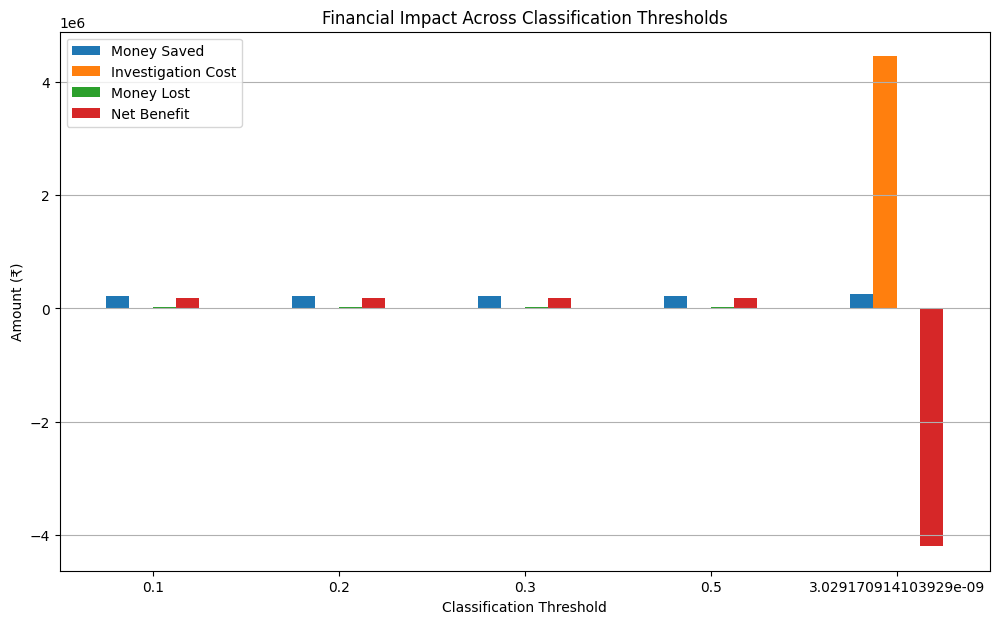

In [196]:
financial_comparison.set_index(

    "Threshold"

)[

    [

        "Money Saved",

        "Investigation Cost",

        "Money Lost",

        "Net Benefit"

    ]

].plot(

    kind="bar",

    figsize=(12,7)

)

plt.title(

    "Financial Impact Across Classification Thresholds"

)

plt.xlabel(

    "Classification Threshold"

)

plt.ylabel(

    "Amount (₹)"

)

plt.xticks(

    rotation=0

)

plt.grid(

    axis="y"

)

plt.show()

In [199]:
best_business_row = business_df.loc[

    business_df["Net Benefit"].idxmax()

]

print("=" * 70)

print("FINAL BUSINESS DECISION")

print("=" * 70)

print(

    "Recommended Threshold:",

    best_business_row["Threshold"]

)

print(

    "True Positives:",

    best_business_row["TP"]

)

print(

    "False Positives:",

    best_business_row["FP"]

)

print(

    "False Negatives:",

    best_business_row["FN"]

)

print(

    "Money Saved: ₹",

    best_business_row["Money Saved"]

)

print(

    "Investigation Cost: ₹",

    best_business_row["Investigation Cost"]

)

print(

    "Money Lost: ₹",

    best_business_row["Money Lost"]

)

print(

    "Net Benefit: ₹",

    best_business_row["Net Benefit"]

)

print("=" * 70)

FINAL BUSINESS DECISION
Recommended Threshold: 0.5
True Positives: 50.0
False Positives: 2.0
False Negatives: 7.0
Money Saved: ₹ 225000.0
Investigation Cost: ₹ 7800.0
Money Lost: ₹ 31500.0
Net Benefit: ₹ 185700.0
